### Análisis de datos II
## UMAP

En esta notebook se ejemplifica la técnica UMAP sobre el dataset de [automóbiles](https://uci-ics-mlr-prod.aws.uci.edu/dataset/10/automobile).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Algunas funciones auxiliares

In [2]:
def stats(feature):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Boxplot
    sns.boxplot(
        x='grupo_label',
    y=feature,
    data=auto,
    palette=['#4b0082', '#ffd700'],
    hue='grupo_label',
    legend=False,
    ax=axes[0]
)

    axes[0].set_title(f'Comparación de {feature}')
    axes[0].set_xlabel('Grupo')
    axes[0].set_ylabel(feature)

    # Histograma
    sns.histplot(
        data=auto,
    x=feature,
    hue='grupo_label',
    common_norm=False,
    kde=True,
    palette=['#4b0082', '#ffd700'],
    ax=axes[1]
)

    axes[1].set_title(f'Distribución de {feature} por Grupo')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Densidad / Cantidad')

    axes[1].legend(labels=['Cluster', 'Resto de autos'])

    plt.tight_layout()
    plt.show()


In [3]:
def stats_cat(feature):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Cantidad de autos por categoría y grupo
    sns.countplot(
        data=auto,
        x=feature,
        hue='grupo_label',
        palette=['#4b0082', '#ffd700'],
        ax=axes[0],
        legend=False
    )

    axes[0].set_title(f'Cantidad de autos por {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=90)

    # Proporción de cada categoría que pertenece a cada grupo
    tabla = pd.crosstab(
        auto[feature],
        auto['grupo_label'],
        normalize='index'
    ) * 100

    tabla.plot(
        kind='bar',
        stacked=True,
        ax=axes[1],
        color=['#ffd700', '#4b0082']
    )

    axes[1].set_title(f'Distribución de {feature} por grupo')
    axes[1].set_xlabel('Grupo')
    axes[1].set_ylabel('Porcentaje')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

---
### DATASET

In [4]:
columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

auto = pd.read_csv(
    '../datasets/automobile/imports-85.data',
    header=None,
    names=columns,
    na_values="?"
)

auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [5]:
auto = auto.dropna(subset=["price"])
auto = auto[auto["price"] != 0].reset_index(drop=True)

### Pipeline

- separar numéricas y categóricas
- imputar faltantes
- escalar las numéricas
- hacer one-hot encoding de las categóricas (para simplificar)
- aplicar UMAP sobre esa representación

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [7]:
target = auto["price"].copy()
X = auto.drop(columns="price")

In [8]:
# Identificar tipos de variables
numeric_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

In [9]:
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        )
    ]
)

X_processed = preprocessor.fit_transform(X)
all_feature_names = preprocessor.get_feature_names_out()

---
### UMAP

**Hiperparámetros**

- `n_neighbors` (Número de vecinos):
  - Valores chicos: Se enfoca en detalles ultra-locales (muestra muchos clústeres pequeños, puede crear ruido).
  - Valores grandes: Mira el panorama general (captura mejor la estructura global de los datos).
- `min_dist` (Distancia mínima):
  - Valores chicos: Los puntos se agrupan de forma muy compacta.
  - Valores grandes: Los puntos se expanden y separan más estéticamente, revelando subestructuras internas.

In [10]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_jobs=1,
    n_neighbors=18,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_processed)

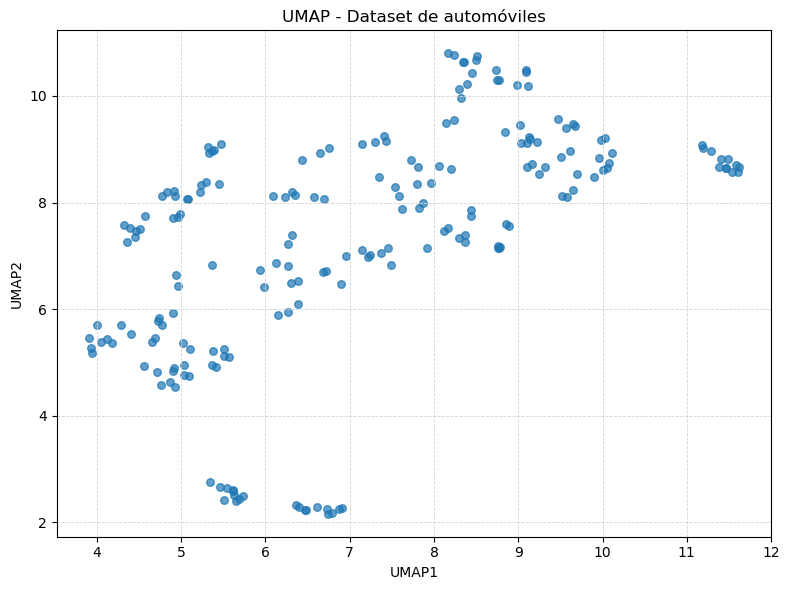

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=30,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP - Dataset de automóviles")

plt.grid(
    color="lightgray",
    linestyle="--",
    linewidth=0.6
)

plt.tight_layout()
plt.show()

Podemos colorear según el precio (que no se usó para armar la estructura de UMAP) para ver si los conglomerados tienen relación o no con el precio.

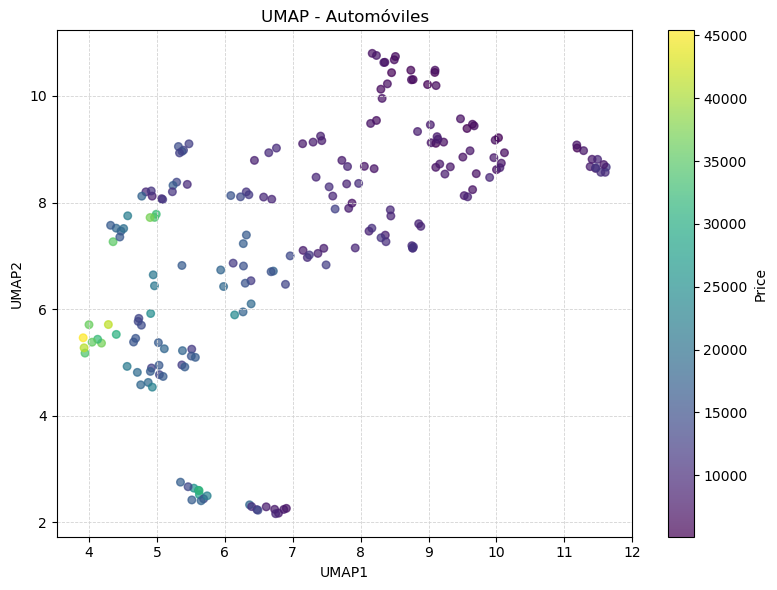

In [12]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=auto["price"],
    s=30,
    alpha=0.7
)

plt.colorbar(scatter, label="Price")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP - Automóviles")

plt.grid(
    color="lightgray",
    linestyle="--",
    linewidth=0.6
)

plt.tight_layout()
plt.show()

#### Qué vemos en el plot

Cada punto en el gráfico representa un automóvil del conjunto de datos.

Los puntos que están cerca unos de otros representan automóviles que tienen características muy similares según el modelo matemático. Los puntos lejanos pertenecen a autos con perfiles muy diferentes.

Los clusters que vemos corresponden a 'familias' de vehículos con características compartidas.

Arriba a la derecha vemos un mini conglomerado de autos bastante alejados del resto. Son de precios bajos, pero de acuerdo a UMAP (que no vio el precio), comparten un perfil técnico o de especificaciones delimitado y distinto al del resto de los autos.

### Inspección cuantitativa

Aislamos los índices del gráfico UMAP. Luego indagamos con distintas estrategias.

In [13]:
# Filtro por coordenadas UMAP aproximadas
auto['es_cluster'] = (X_umap[:, 0] > 11) & (X_umap[:, 1] > 4 )
# también podría filtrar por valor de target, ejemplo:
# auto['es_cluster'] = (X_umap[:, 0] < 6) & (X_umap[:, 1] < 6) & (auto['price'] < 15000)

# Crea una columna con nombres de texto explícitos para los charts
auto['grupo_label'] = auto['es_cluster'].map({False: 'Resto de autos', True: 'Cluster'})

auto[auto['es_cluster']].head(2)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,es_cluster,grupo_label
134,2,83.0,subaru,gas,std,two,hatchback,fwd,front,93.7,...,3.62,2.36,9.0,69.0,4900.0,31,36,5118.0,True,Cluster
135,2,83.0,subaru,gas,std,two,hatchback,fwd,front,93.7,...,3.62,2.64,8.7,73.0,4400.0,26,31,7053.0,True,Cluster


**Opción 1)**
Realizamos un EDA de los elementos del cluster de interés, en forma aislada o contrastando el cluster versus el resto.

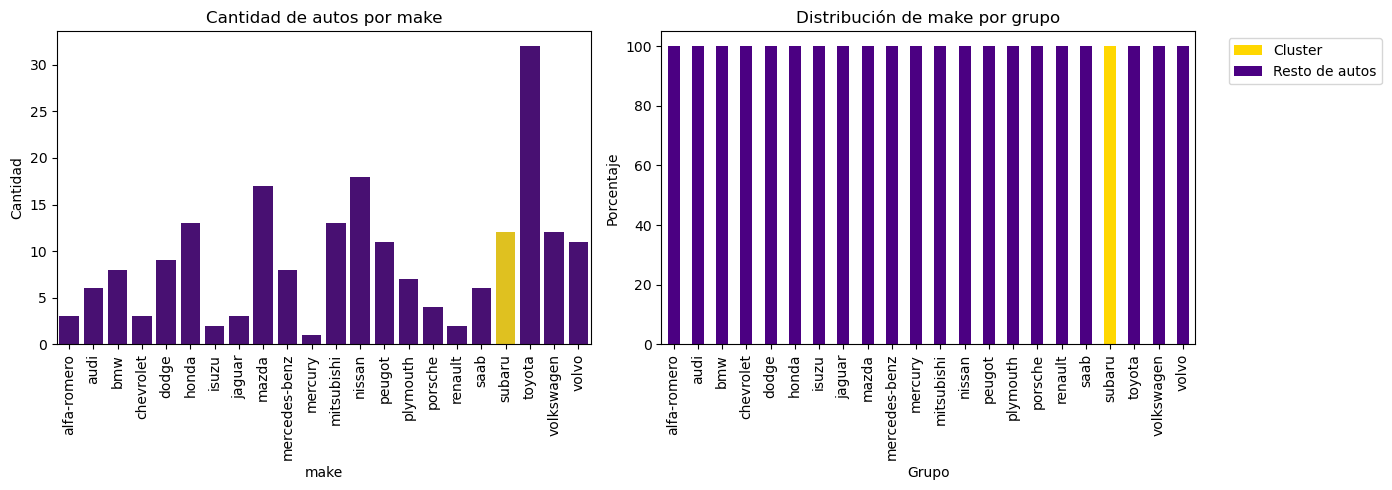

In [14]:
stats_cat('make')

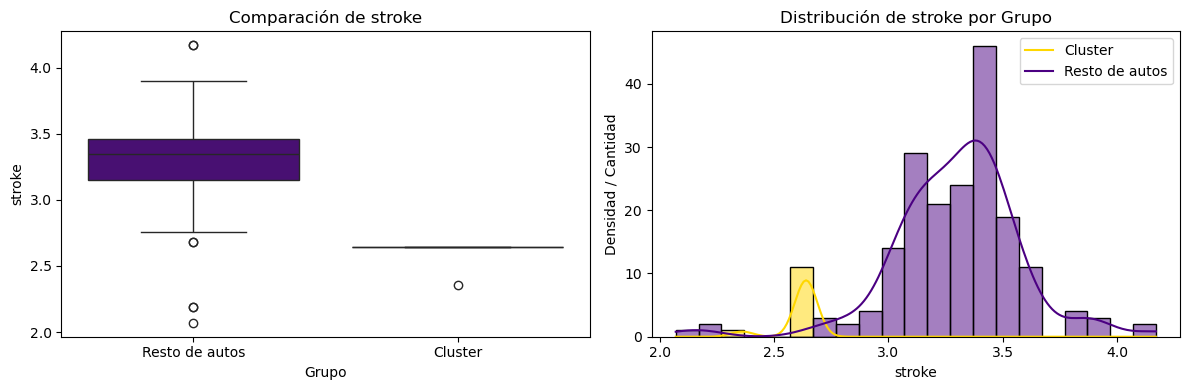

In [15]:
stats('stroke')

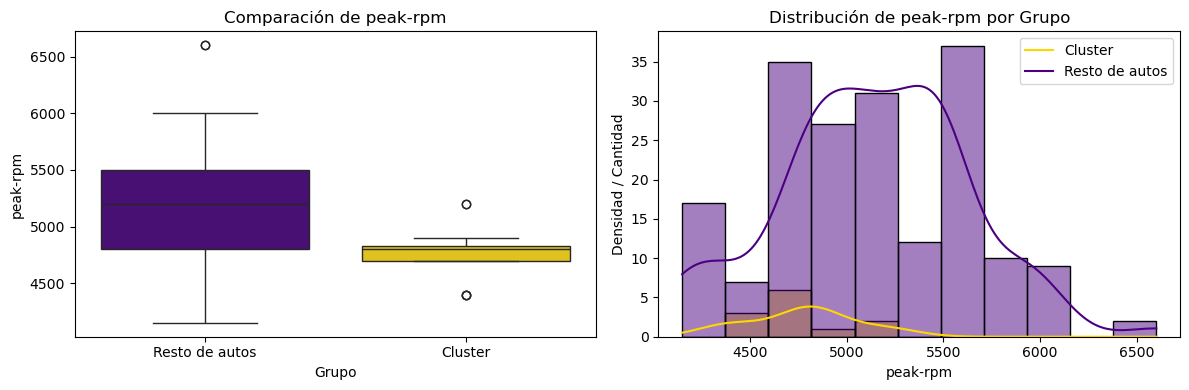

In [16]:
stats('peak-rpm')

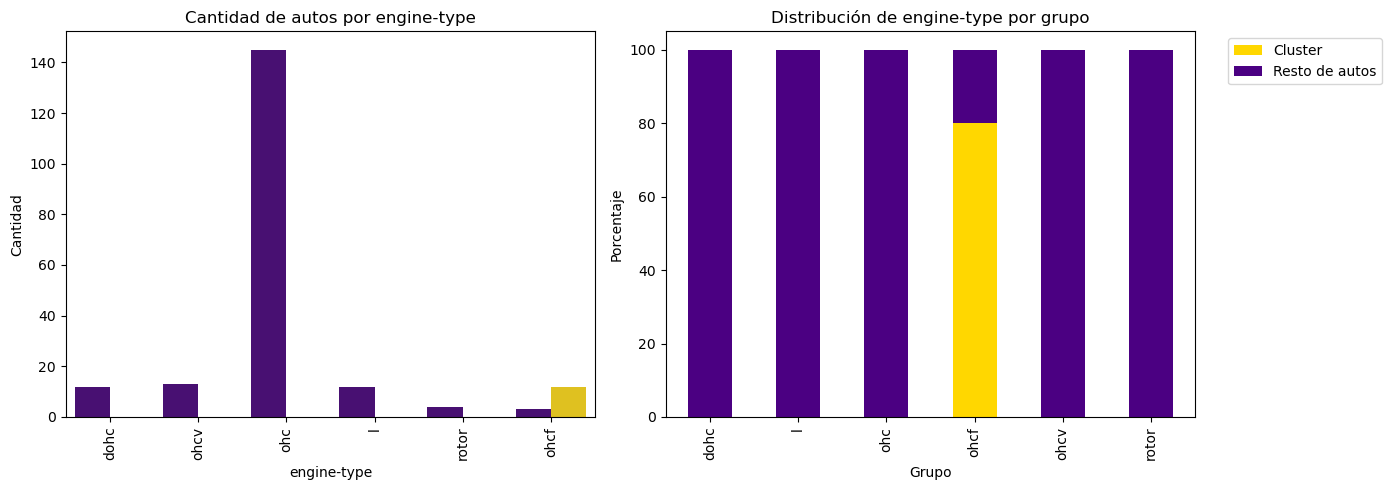

In [17]:
stats_cat('engine-type')

**Opción 2)**
usar un modelo de clasificación simple (como un árbol de decisión) para descubrir qué variables exactas explican por qué esos puntos específicos aparecen separados del resto.

In [18]:
from sklearn.tree import DecisionTreeClassifier

# entrenamos un árbol usando los datos ya transformados (X_processed)
y = auto['es_cluster']
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_processed, y)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
# creamos un ranking con las variables más importantes
importances_df = pd.DataFrame({
    'Caracteristica': all_feature_names,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Top 5 características que definen al cluster:")
print(importances_df.head(5))

Top 5 características que definen al cluster:
               Caracteristica  Importancia
33           cat__make_subaru          1.0
0              num__symboling          0.0
47      cat__body-style_wagon          0.0
53      cat__engine-type_dohc          0.0
52  cat__engine-location_rear          0.0


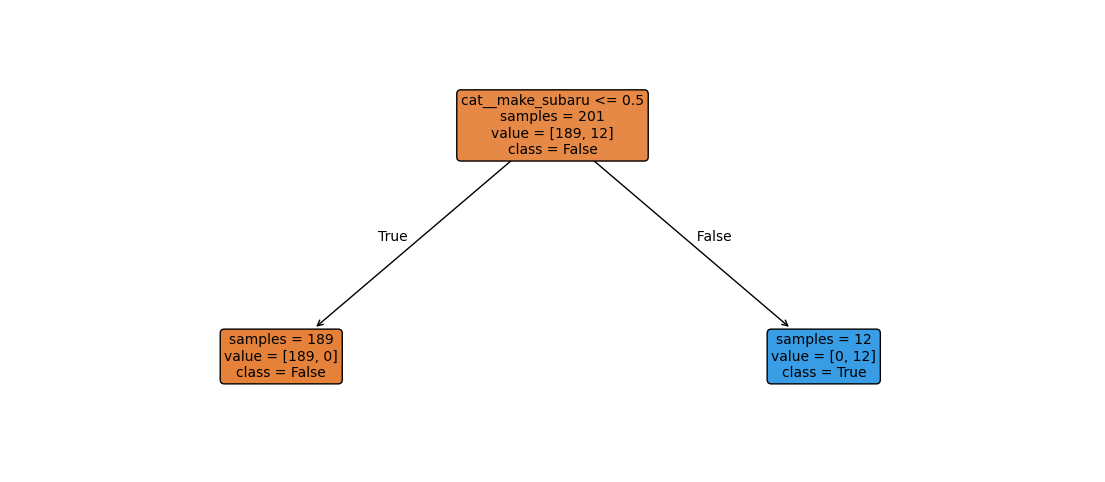

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 6))
plot_tree(modelo, feature_names=all_feature_names,
    class_names=modelo.classes_.astype(str),
    filled=True, rounded=True, impurity=False, fontsize=10)
plt.show()

Inspeccionamos específicamente las features que usó el árbol.

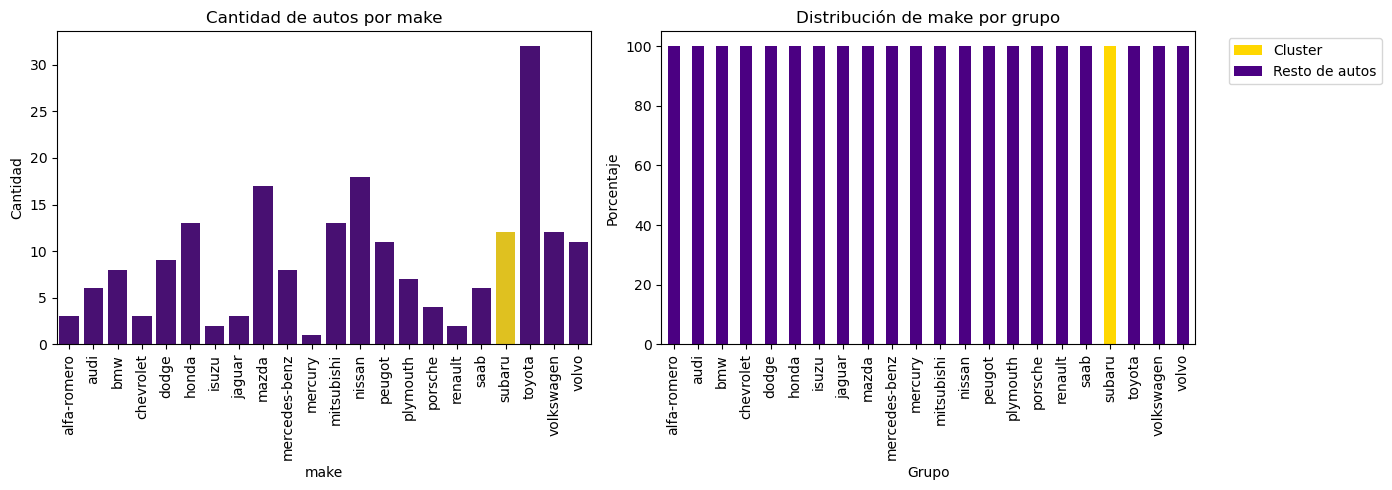

In [21]:
stats_cat('make')

**Opción 3)**
Si antes de entrenar separamos en train y test, podemos también ver la importancia con PFI.

**En este ejemplo miramos clusters individuales. También podemos inspeccionar regiones adyacentes, lejanas, comparar clusters entre sí, etc.**